In [1]:
#load tidyverse for some needed packages
library(tidyverse)
#load our dataset
co2 <- read.csv("co2gdp_all.csv")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.0 ──

✔ ggplot2 4.0.3     ✔ purrr   1.2.2
✔ tibble  3.3.1     ✔ dplyr   1.2.1
✔ tidyr   1.3.2     ✔ stringr 1.6.0
✔ readr   2.2.0     ✔ forcats 1.0.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()



In [2]:
#examine data
co2

countryname,countrycode,gdppercapitapppconstant2005inter,co2percaptons,gdp_dollars
<chr>,<chr>,<dbl>,<dbl>,<dbl>
,,NA,NA,NA
,,NA,NA,NA
Afghanistan,AFG,NA,NA,NA
Albania,ALB,5.211804,1.1709810,5211.804
Algeria,DZA,5.844023,5.9886600,5844.023
American Samoa,ASM,NA,NA,NA
Andorra,ADO,NA,NA,NA
Angola,AGO,3.182347,0.5046268,3182.347
Antigua and Barbuda,ATG,14.195593,5.0510570,14195.590


In [3]:
#eliminate missing values
co2 <-subset(co2, is.na(co2[,"co2percaptons"])==F)
co2 <-subset(co2, is.na(co2[,"gdp_dollars"])==F)

In [4]:
co2

,countryname,countrycode,gdppercapitapppconstant2005inter,co2percaptons,gdp_dollars
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
4,Albania,ALB,5.2118040,1.1709810,5211.8040
5,Algeria,DZA,5.8440231,5.9886600,5844.0230
8,Angola,AGO,3.1823467,0.5046268,3182.3470
9,Antigua and Barbuda,ATG,14.1955930,5.0510570,14195.5900
10,Argentina,ARG,10.0026860,3.6917790,10002.6900
11,Armenia,ARM,3.6429522,1.2041070,3642.9520
13,Australia,AUS,33.6148120,16.2156100,33614.8100
14,Austria,AUT,33.6324550,8.5365590,33632.4600
15,Azerbaijan,AZE,3.6621367,3.7726290,3662.1370


In [5]:
#generate random samples - runif draws a uniform random number.  10% of these will be less than 0.1
#drawing sample 1
co2[,"sample1"]<-runif(nrow(co2))<0.1
#drawing sample 2
co2[,"sample2"]<-runif(nrow(co2))<0.1
#for simplicity, make a new dataset with each of our samples
co2_sample1 <-subset(co2,co2[,"sample1"])
co2_sample2 <-subset(co2, co2[,"sample2"])

In [6]:
#view sample 1
co2_sample1

,countryname,countrycode,gdppercapitapppconstant2005inter,co2percaptons,gdp_dollars,sample1,sample2
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>
5,Algeria,DZA,5.8440231,5.9886600,5844.0230,TRUE,FALSE
18,Bangladesh,BGD,1.0265542,0.2466768,1026.5540,TRUE,FALSE
27,Bosnia and Herzegovina,BIH,5.6798521,3.9900420,5679.8520,TRUE,FALSE
68,France,FRA,30.2517080,6.1690610,30251.7100,TRUE,FALSE
74,Ghana,GHA,1.1191412,0.3256641,1119.1410,TRUE,FALSE
84,Honduras,HND,3.2349981,1.1351420,3234.9980,TRUE,FALSE
87,Iceland,ISL,33.6252820,7.6245580,33625.2800,TRUE,FALSE
94,Israel,ISR,21.8781620,10.4627100,21878.1600,TRUE,FALSE
98,Jordan,JOR,4.1383140,3.1097420,4138.3140,TRUE,FALSE


In [7]:
#view sample 2
co2_sample2

,countryname,countrycode,gdppercapitapppconstant2005inter,co2percaptons,gdp_dollars,sample1,sample2
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>
9,Antigua and Barbuda,ATG,14.195593,5.0510570,14195.590,FALSE,TRUE
43,China,CHN,3.727037,3.8619440,3727.037,FALSE,TRUE
72,Georgia,GEO,3.180784,0.8652728,3180.784,FALSE,TRUE
73,Germany,DEU,30.153245,9.7925340,30153.240,FALSE,TRUE
92,Ireland,IRL,36.703514,10.4007600,36703.520,FALSE,TRUE
107,Latvia,LVA,11.885704,3.0662380,11885.700,TRUE,TRUE
119,Malaysia,MYS,11.325906,7.0430560,11325.910,FALSE,TRUE
141,New Zealand,NZL,24.358572,7.7167200,24358.570,FALSE,TRUE
158,Qatar,QAT,69.451883,69.1590600,69451.880,TRUE,TRUE


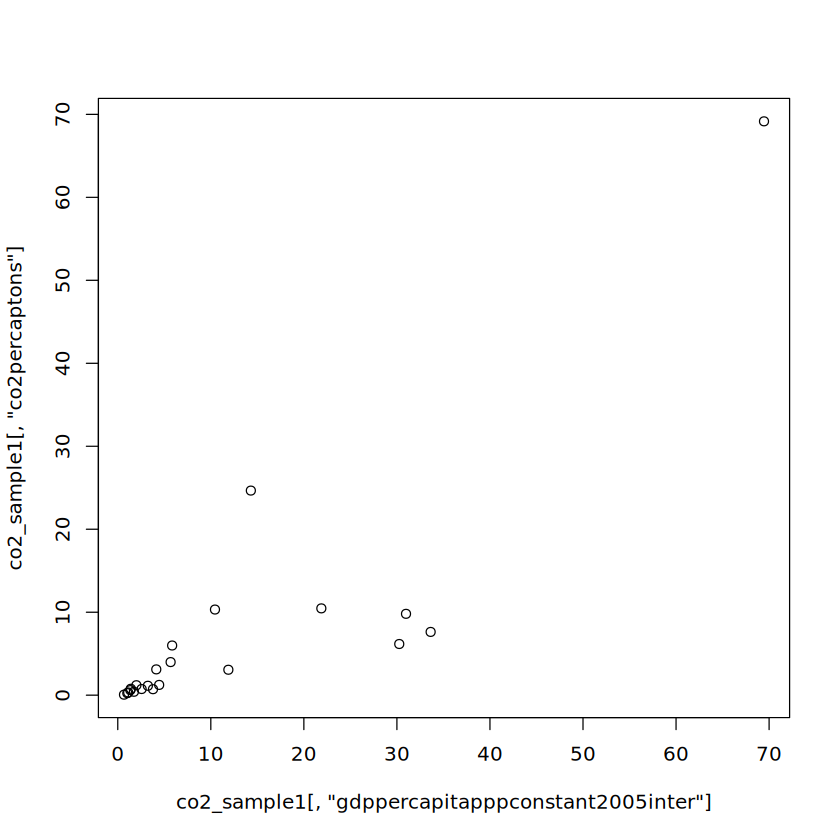

In [8]:
#scatter plot sample 1
plot(co2_sample1[,"gdppercapitapppconstant2005inter"],co2_sample1[,"co2percaptons"])

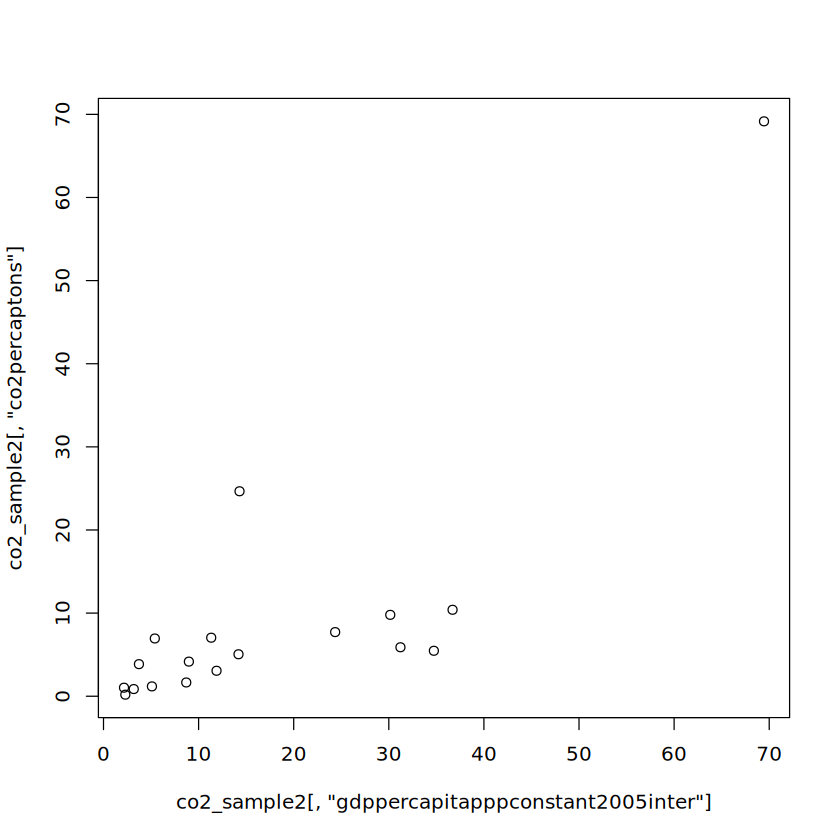

In [9]:
#scatter plot sample 2
plot(co2_sample2[,"gdppercapitapppconstant2005inter"],co2_sample2[,"co2percaptons"])

In [10]:
#regress co2 on gdp in sample 1
s1_reg <- lm(co2percaptons ~gdppercapitapppconstant2005inter, data = co2_sample1)
s1_reg



Call:
lm(formula = co2percaptons ~ gdppercapitapppconstant2005inter, 
    data = co2_sample1)

Coefficients:
                     (Intercept)  gdppercapitapppconstant2005inter  
                         -1.7628                            0.7662  


In [11]:
#regress co2 on gdp in sample 2
s2_reg <- lm(co2percaptons ~gdppercapitapppconstant2005inter, data = co2_sample2)
s2_reg


Call:
lm(formula = co2percaptons ~ gdppercapitapppconstant2005inter, 
    data = co2_sample2)

Coefficients:
                     (Intercept)  gdppercapitapppconstant2005inter  
                         -3.4117                            0.7222  


In [12]:
#view standard errors
summary(s1_reg)


Call:
lm(formula = co2percaptons ~ gdppercapitapppconstant2005inter, 
    data = co2_sample1)

Residuals:
     Min       1Q   Median       3Q      Max 
-16.3758  -0.4144   1.2269   1.4533  17.7089 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                       -1.7628     2.1189  -0.832    0.415    
gdppercapitapppconstant2005inter   0.7662     0.1053   7.277 4.87e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.015 on 20 degrees of freedom
Multiple R-squared:  0.7259,	Adjusted R-squared:  0.7122 
F-statistic: 52.96 on 1 and 20 DF,  p-value: 4.873e-07


In [13]:
library(sandwich)
library(lmtest)

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




In [14]:
coeftest(s1_reg, vcov = vcovHC)


t test of coefficients:

                                 Estimate Std. Error t value Pr(>|t|)
(Intercept)                      -1.76275    3.46255 -0.5091   0.6163
gdppercapitapppconstant2005inter  0.76618    0.47000  1.6302   0.1187
